# NumPy Hands-on Lab: From Arrays to Image Analysis

## Student Practice Notebook

**Name:** Sankalp Tiwari  
**Register Number:** AP24110010356  
**Date:** 07/08/2026  

## Learning Objectives

After completing this lab, you will be able to:

- Create and manipulate NumPy arrays
- Understand array properties and dimensions
- Perform indexing and slicing
- Apply mathematical operations
- Understand and explain broadcasting
- Analyze images using NumPy arrays
- Perform basic image transformations
- Explain *why* NumPy is used in real ML/Data Science pipelines, not just *how*

### How to use this notebook
- **Demonstration** cells: run them, read the output, understand it.
- **Practice** cells: write your own code — don't copy the demo verbatim.
- **Predict-then-run**: before running some cells, you'll be asked to *predict* the output first. Write your prediction in the markdown cell, then run and compare.
- **Reflection**: short written answers, in your own words.


## Part 1: Introduction to NumPy

NumPy (Numerical Python) is a Python library used for efficient numerical computation.

**Why not just use Python lists?** Python lists store objects with overhead per element and loop in pure Python. NumPy arrays store raw numbers in contiguous memory and use compiled C code for operations — this is called **vectorization**. That's why NumPy is used everywhere in:

- Data Science (pandas is built on NumPy)
- Machine Learning (feeding data into models as arrays/tensors)
- Image Processing (an image *is* a NumPy array)
- Scientific Computing

Let's actually *see* the speed difference before we take it on faith.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy is ready!")


NumPy is ready!


### Demonstration: Loops vs. Vectorization (the "why" behind NumPy)

Below we add 1 to a million numbers two ways: a plain Python loop, and a NumPy array operation.
Run this cell and look at the timing output.


In [3]:
import time

n = 1_000_000
python_list = list(range(n))
numpy_array = np.arange(n)

start = time.time()
result_list = [x + 1 for x in python_list]
loop_time = time.time() - start

start = time.time()
result_array = numpy_array + 1
vector_time = time.time() - start

print(f"Python loop time : {loop_time:.5f} seconds")
print(f"NumPy vector time: {vector_time:.5f} seconds")
print(f"NumPy was about {loop_time/vector_time:.0f}x faster")


Python loop time : 0.14842 seconds
NumPy vector time: 0.00820 seconds
NumPy was about 18x faster


**Reflection (write your answer):** Based on the timing above, in your own words, why is NumPy faster than a Python loop for this kind of operation?

*Your answer:* Because Numpy store numbers in raw memory locations so that it is easy for a program to look and produce the desired outputs also it is a predefined compiled C code whereas when we are looping through the python code it loops through each and every element which consumes more time.


## Part 2: Creating NumPy Arrays

### Demonstration

In [4]:
arr = np.array([10,20,30,40,50])
arr


array([10, 20, 30, 40, 50])

### Student Practice

Create an array containing:

5, 10, 15, 20, 25

Write your code below (do not just copy the demo — change the numbers yourself):


In [5]:
a = np.array([5,10,15,20,25])
a


array([ 5, 10, 15, 20, 25])

## Part 3: Array Properties

Important properties:

- `ndim` : Number of dimensions
- `shape` : Size of each dimension
- `size` : Total number of elements
- `dtype` : Data type

**Predict first:** for the array `arr` from Part 2, what do you *expect* `ndim`, `shape`, `size`, and `dtype` to be? Write your guess below before running the next cell.

*Your prediction:*


In [6]:
arr.ndim, arr.shape, arr.size, arr.dtype


(1, (5,), 5, dtype('int64'))

### Observation

Was your prediction correct? If not, what did you get wrong and why? - I got shape wrong I thought that it works same as dimension so my initial answer was 1 but instead shape is same as size.

Dimension: 1D

Shape: 5

Size: 5

Data Type: int64


## Part 4: Special Arrays

These are commonly used to initialize data — for example, `zeros` is often used to create an empty "canvas" array before filling in real values (you'll see this again in the image section).


In [7]:
np.zeros((3,3))


array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [8]:
np.ones((4,4))


array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [9]:
np.eye(3)


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Student Practice

Create a `5x5` array of all zeros, and a `2x6` array of all ones. Write both below.


In [10]:
# Write your answer here
np.zeros((5,5))

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [11]:
np.ones((2,6))

array([[1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.]])

## Part 5: Sequence Generation

In [12]:
np.arange(0,50,5)


array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

In [13]:
np.linspace(0,100,10)


array([  0.        ,  11.11111111,  22.22222222,  33.33333333,
        44.44444444,  55.55555556,  66.66666667,  77.77777778,
        88.88888889, 100.        ])

### Student Practice

`np.arange` and `np.linspace` both generate sequences but work differently.

1. Use `np.arange` to generate even numbers from 2 to 20.
2. Use `np.linspace` to generate 5 evenly spaced numbers between 0 and 1.
3. In one sentence, write the difference between `arange` (step-based) and `linspace` (count-based).


In [14]:
# Write your answer here
np.arange(2,21,2)

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

In [15]:
np.linspace(0,1,5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

arange  -> (start,stop,distance between numbers)
linspace -> (start,stop included, total number wanted in array)

## Part 6: Random Numbers

In [16]:
np.random.rand(5)


array([0.37349091, 0.42944166, 0.72464893, 0.02745818, 0.03014465])

In [17]:
np.random.randint(1,100,10)


array([24, 15, 52, 77, 71, 71, 38,  6, 19, 59])

## Part 7: Reshaping Arrays

Reshape changes the *structure* of an array without changing the data.

**Rule: the total number of elements must stay the same.** `3x4 = 12` elements, so you can reshape into any combination of dimensions that multiplies to 12 (e.g. `2x6`, `4x3`, `1x12`, `12x1`).


In [18]:
a = np.arange(12)
a


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [19]:
a.reshape(3,4)

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

### Student Practice — valid shapes

Try reshaping `a` into these shapes. Write each as a separate line:
- 2 x 6
- 4 x 3
- 6 x 2


In [20]:
# Practice here
a.reshape(2,6)

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [21]:
a.reshape(4,3)

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [22]:
a.reshape(6,2)

array([[ 0,  1],
       [ 2,  3],
       [ 4,  5],
       [ 6,  7],
       [ 8,  9],
       [10, 11]])

### Student Practice — break it on purpose

Now try `a.reshape(5,3)`. This should throw an error because 5 × 3 = 15 ≠ 12.

Run it, read the error message, then answer: **why did it fail, and what rule does it confirm about reshape?**

*Your answer:* it failed beacuse it cannot reshape a array of size 12 into a new array of shape 5,3 i.e 5X3 = 15
but 15 is not equal to the original total elements which is 12. It confirms that it is required that you must ensue that you are creating a array from the multiple of the total elements


In [23]:
# Try the invalid reshape here and observe the error
a.reshape(5,3)

ValueError: cannot reshape array of size 12 into shape (5,3)

## Part 8: Indexing and Slicing

In [24]:
matrix = np.arange(1,10).reshape(3,3)
matrix


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [25]:
# Extract first row
matrix[0]


array([1, 2, 3])

In [26]:
# Extract first column
matrix[:,0]


array([1, 4, 7])

### Student Practice

Using `matrix` above, write code to extract:
1. The last row
2. The last column
3. The single element in the middle (row 1, column 1)
4. The bottom-right 2x2 sub-matrix


In [27]:
# Write your answer here
matrix[2]

array([7, 8, 9])

In [28]:
matrix[:,2]

array([3, 6, 9])

In [29]:
matrix[1,1]

np.int64(5)

In [30]:
mat = matrix[-2:,-2:]
mat

array([[5, 6],
       [8, 9]])

## Part 9: Mathematical Operations

In [31]:
marks = np.array([60,70,80,90])

marks + 5


array([65, 75, 85, 95])

In [32]:
marks * 2


array([120, 140, 160, 180])

### Student Practice

A student scored `marks = [55, 62, 48, 91, 73]` but every question was later found to be worth 1 extra bonus mark, and then the whole test was scaled to be out of 150 (currently out of 100, so multiply by 1.5).

Write the NumPy code to: (1) add the bonus mark to every score, then (2) scale to out of 150.


In [33]:
# Write your answer here
mark = np.array([55, 62, 48, 91, 73])
mark = mark + 1
mark

array([56, 63, 49, 92, 74])

In [34]:
mark = mark * 1.5
mark

array([ 84. ,  94.5,  73.5, 138. , 111. ])

## Part 10: Broadcasting

Broadcasting lets NumPy perform operations between arrays of **different shapes**, without writing an explicit loop, by "stretching" the smaller array to match the larger one — as long as their shapes are compatible.

**The basic rule:** starting from the trailing (rightmost) dimension, two dimensions are compatible if they're equal, or one of them is 1. NumPy then virtually repeats the size-1 dimension to match.

You already used broadcasting in Part 9 (`marks + 5`) — a single number (shape `()`) was broadcast across the whole array. Here's a less obvious example: a 1D array broadcast across a 2D array.


In [35]:
salary = np.array([30000,40000,50000])

salary * 1.10


array([33000., 44000., 55000.])

In [36]:
# A less obvious broadcasting example: adding a 1D array to every row of a 2D array
grid = np.ones((3,3))       # shape (3,3)
row_bonus = np.array([1,2,3])  # shape (3,)

grid + row_bonus


array([[2., 3., 4.],
       [2., 3., 4.],
       [2., 3., 4.]])

### Student Practice — predict then check

Before running the next cell, predict the output shape and values on paper.

`np.array([[1],[2],[3]]) + np.array([10,20,30])`

(Hint: one array has shape `(3,1)`, the other `(3,)`. Think about how each dimension aligns.)

*Your prediction:* [[11],
                    [22],
                    [33]]


In [37]:
# Run this after writing your prediction above, and compare
np.array([[1],[2],[3]]) + np.array([10,20,30])


array([[11, 21, 31],
       [12, 22, 32],
       [13, 23, 33]])

**Reflection:** In your own words, explain broadcasting with an example of your own (not one from this notebook).

*Your answer:* Its like a message when you hit send each and every device recives it in a group. Similarly, when we are doing a operation in a array it goes for each and every element in an array.
Example - price[55,60,90,450]
price = price + 50
Output - array([105,110,140,500])


## Part 11: Filtering Data (Boolean Indexing)

In [38]:
marks = np.array([45,67,89,32,90,55])

marks[marks > 60]


array([67, 89, 90])

### Student Practice

Using the `marks` array above:
1. Extract all marks that are failing (below 40).
2. Count how many students scored above 80 (hint: `.sum()` on a boolean array counts `True` values).
3. Replace all failing marks with 0 using `np.where`.


In [39]:
# Write your answer here
marks[marks < 40]

array([32])

In [40]:
marks[marks > 80].sum()

np.int64(179)

In [41]:
marks = np.where(marks < 40,0,marks)
marks

array([45, 67, 89,  0, 90, 55])

## Part 12: Joining Arrays

In [42]:
a=np.array([1,2,3])
b=np.array([4,5,6])

np.concatenate([a,b])


array([1, 2, 3, 4, 5, 6])

## Part 13: Splitting Arrays

In [44]:
x=np.arange(12)

x


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [46]:
np.split(x,3)


[array([0, 1, 2, 3]), array([4, 5, 6, 7]), array([ 8,  9, 10, 11])]

### Student Practice

1. Split `x` into 4 equal parts instead of 3.
2. Try `np.split(x, 5)` — this should fail. Read the error and explain in one sentence why splitting into 5 doesn't work for 12 elements.


In [47]:
# Write your answer here
np.split(x,4)

[array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8]), array([ 9, 10, 11])]

In [48]:
np.split(x,5) # It failed because 11 and 12 still remains after spliting in 5 ie some portion will be left

ValueError: array split does not result in an equal division

# Part 14: Image Analysis Using NumPy

## Why this matters for ML

A digital image **is** a NumPy array — this is exactly the data format used to feed images into computer vision models (e.g. CNNs). Every preprocessing step you do below (resizing, cropping, normalizing pixel values, flipping for data augmentation) is a real step used in production ML image pipelines, not just a classroom exercise.

## Image Shape Guidelines

A colour image is represented as:

`(height, width, channels)`

Example: `512 x 512 x 3` means:
- Height = 512 pixels
- Width = 512 pixels
- RGB colour channels = 3

**Avoid very large images** — a `4000 x 4000 x 3` image has 48 million individual pixel values. That's a lot to process and display.

Recommended:
- Practice: 300x300 pixels
- Processing: 512x512 pixels


In [49]:
from google.colab import files

uploaded = files.upload()


Saving images.png to images (1).png


In [50]:
# The 'uploaded' variable is a dictionary: {filename: file_bytes}
# This line grabs the filename automatically instead of you typing it by hand
image_filename = list(uploaded.keys())[0]
print("Uploaded file:", image_filename)


Uploaded file: images (1).png


> **Note:** the cell above only works in Google Colab. If you're running this notebook locally (Jupyter/VS Code), skip it and instead set `image_path = "your_local_file.jpg"` directly in the next cell.

Upload an image file and note its name below:

Image name: images(1).png


In [51]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# TASK: Load your uploaded image and convert it to a NumPy array.
# 1. Open the image with PIL: Image.open(image_filename)
# 2. Convert it to a NumPy array with np.array(...)
# 3. Print its .shape
image = Image.open(image_filename)
img_array = np.array(image)  # replace this line with your code

print("Image shape:", img_array.shape)

Image shape: (447, 447)


## Image Display

**Do not print the complete image array** (it's thousands of numbers and unreadable). Instead:
- Use `image.shape` to check dimensions
- Use `plt.imshow(...)` to *see* the image visually

### Student Practice
Display your uploaded image using `plt.imshow()` and turn off the axis with `plt.axis("off")`.


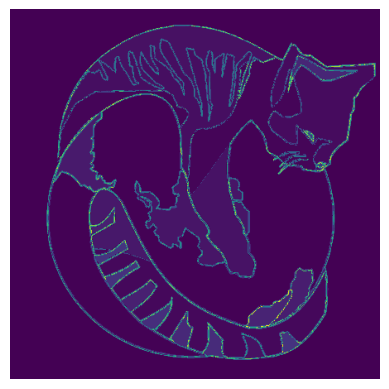

In [53]:
# Write your code here to display img_array
plt.imshow(img_array)
plt.axis("off")
plt.show()

## Image Cropping

### Student Practice
Crop the **center 200x200 region** of your image (not a random corner — think about how to calculate the center offset from `img_array.shape`), store it in a variable called `crop`, and display it.


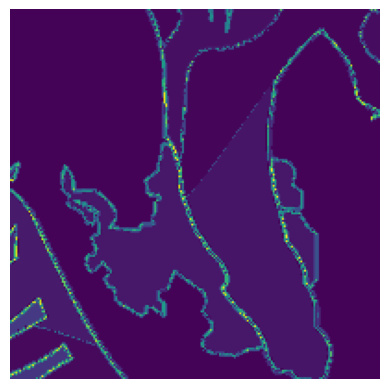

In [54]:
# Write your cropping code here
height, width = img_array.shape[:2]

start_y = (height - 200) // 2
start_x = (width - 200) // 2

crop = img_array[start_y:start_y + 200, start_x:start_x + 200]

plt.imshow(crop)
plt.axis("off")
plt.show()

### Quick demo: showing multiple images side by side

You'll want to display more than one image at once in the tasks below (e.g. two flipped versions, or three RGB channels). `plt.subplots()` lets you do this in a grid. Study this small example, then reuse the pattern.


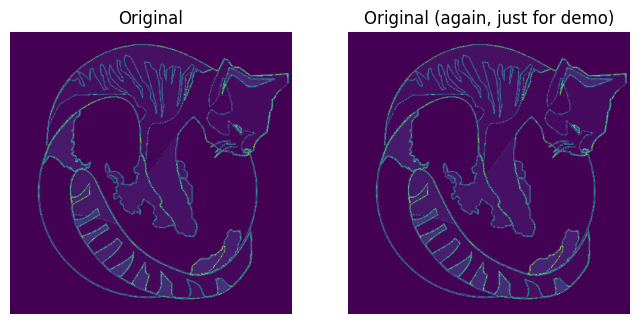

In [55]:
# Demo: showing 2 plots side by side using plt.subplots
fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_array)
axes[1].set_title("Original (again, just for demo)")
axes[1].axis("off")

plt.show()


## Image Flipping

### Student Practice
Produce and display both a vertical flip and a horizontal flip of your image using slicing (`[::-1]`), without using any built-in flip function.


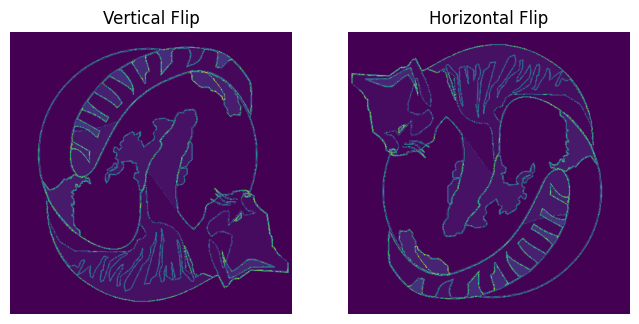

In [56]:
# Write your flipping code here
vertical_flip = img_array[::-1, :]
horizontal_flip = img_array[:, ::-1]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(vertical_flip)
axes[0].set_title("Vertical Flip")
axes[0].axis("off")

axes[1].imshow(horizontal_flip)
axes[1].set_title("Horizontal Flip")
axes[1].axis("off")

plt.show()

## RGB Channel Analysis

RGB channels:

- 0 - Red
- 1 - Green
- 2 - Blue

### Student Practice
Extract the red, green, and blue channels separately, and display each one using `plt.imshow(channel, cmap="gray")` so you can see which areas of the image are strongest in each color.


In [60]:
# Write your RGB channel code here
red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(red, cmap="gray")
axes[0].set_title("Red Channel")
axes[0].axis("off")

axes[1].imshow(green, cmap="gray")
axes[1].set_title("Green Channel")
axes[1].axis("off")

axes[2].imshow(blue, cmap="gray")
axes[2].set_title("Blue Channel")
axes[2].axis("off")

plt.show()

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

## Brightness Analysis

### Student Practice
Calculate the average brightness of your image using `np.mean()`. Then calculate the average brightness of just the red channel, just the green channel, and just the blue channel. Which channel is brightest? Write your answer below the code.


In [61]:
# Write your brightness code here
overall_brightness = np.mean(img_array)

red_brightness = np.mean(red)
green_brightness = np.mean(green)
blue_brightness = np.mean(blue)

print("Overall brightness:", overall_brightness)
print("Red channel brightness:", red_brightness)
print("Green channel brightness:", green_brightness)
print("Blue channel brightness:", blue_brightness)

brightness_values = {
    "Red": red_brightness,
    "Green": green_brightness,
    "Blue": blue_brightness
}

brightest_channel = max(brightness_values, key=brightness_values.get)

print("Brightest channel:", brightest_channel)

NameError: name 'red' is not defined

*Your answer:* The red channel is the brightest because its average brightness is higher than the green and blue channels.


## Thresholding

Convert the image into pure black-and-white using `np.where()`.

### Student Practice
1. Convert the image to grayscale by averaging the 3 channels (`axis=2`).
2. Use `np.where(gray > 128, 255, 0)` to create a binary (black/white) version.
3. Display the result.
4. Try a different threshold (e.g. 100 or 180) and observe how it changes the result.


In [62]:
# Write your thresholding code here
gray = np.mean(img_array, axis=2)

binary = np.where(gray > 128, 255, 0)

plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

AxisError: axis 2 is out of bounds for array of dimension 2

# Mini Project: Image Analyzer

Write a single program (you can reuse code from above) that prints/displays all of the following for your uploaded image, in order:

1. Image height, width, and number of channels
2. Average brightness (overall, and per channel)
3. The cropped center region
4. Both flipped versions (vertical and horizontal)
5. All 3 RGB channels shown separately
6. The thresholded (black/white) version

### Self-check before you submit
- [ ] I wrote the code myself rather than only uncommenting given code
- [ ] I can explain what every line does, not just that it runs
- [ ] My image display uses `plt.axis("off")` and looks correct
- [ ] I answered all reflection questions in my own words

## Reflection Questions

1. Why is NumPy faster than Python lists? (Refer back to your Part 1 answer — refine it if needed.)
NumPy is faster because its arrays store data efficiently and its operations are implemented in optimized code. NumPy can perform calculations on many values at once instead of using a Python loop for every element.

2. Explain broadcasting with an example of your own.
Broadcasting allows NumPy to perform operations between arrays with compatible shapes without manually writing loops. For example, if an array contains [10, 20, 30], adding 5 gives [15, 25, 35]. NumPy automatically applies the 5 to every element

3. What does image shape `(512,512,3)` represent?
It represents an image with a height of 512 pixels, a width of 512 pixels, and 3 color channels: red, green, and blue.
4. Why should we avoid printing complete image arrays?
A complete image array contains thousands or millions of pixel values, so printing it produces a huge and difficult-to-read output. It is better to use shape to inspect its dimensions and imshow() to display the image visually.
5. Explain RGB channels.
RGB stands for Red, Green, and Blue. Each pixel in a color image contains three values representing the intensity of these three channels. Different combinations of these values produce different colors.
6. Where might you use this exact image-array workflow in a real machine learning project (e.g. what comes right before feeding an image into a CNN)?
This workflow can be used during image preprocessing before an image is given to a CNN. Images can be loaded, resized, cropped, converted to arrays, normalized, and augmented using operations such as flipping before being passed to the machine learning model.

In [63]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image
image = Image.open(image_filename)
img_array = np.array(image)

height, width = img_array.shape[:2]
channels = img_array.shape[2]

print("Image height:", height)
print("Image width:", width)
print("Number of channels:", channels)

# 2. Brightness
red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

overall_brightness = np.mean(img_array)
red_brightness = np.mean(red)
green_brightness = np.mean(green)
blue_brightness = np.mean(blue)

print("\nBrightness:")
print("Overall:", overall_brightness)
print("Red:", red_brightness)
print("Green:", green_brightness)
print("Blue:", blue_brightness)

# 3. Center crop
start_y = (height - 200) // 2
start_x = (width - 200) // 2

crop = img_array[start_y:start_y + 200, start_x:start_x + 200]

# 4. Flips
vertical_flip = img_array[::-1, :]
horizontal_flip = img_array[:, ::-1]

# 5. RGB channels
# 6. Threshold
gray = np.mean(img_array, axis=2)
binary = np.where(gray > 128, 255, 0)

# Display everything
fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes[0, 0].imshow(crop)
axes[0, 0].set_title("Center Crop")

axes[0, 1].imshow(vertical_flip)
axes[0, 1].set_title("Vertical Flip")

axes[0, 2].imshow(horizontal_flip)
axes[0, 2].set_title("Horizontal Flip")

axes[0, 3].imshow(red, cmap="gray")
axes[0, 3].set_title("Red Channel")

axes[1, 0].imshow(green, cmap="gray")
axes[1, 0].set_title("Green Channel")

axes[1, 1].imshow(blue, cmap="gray")
axes[1, 1].set_title("Blue Channel")

axes[1, 2].imshow(binary, cmap="gray")
axes[1, 2].set_title("Thresholded")

axes[1, 3].imshow(img_array)
axes[1, 3].set_title("Original")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

IndexError: tuple index out of range

# Part 15: Text Analysis Using NumPy (NLP Track)

## Why this matters for ML/NLP

Before any NLP model (sentiment classifier, spam detector, chatbot) can process text, the text must be converted into numbers — this is called **vectorization**. NumPy arrays are the underlying data structure for almost every text representation: word counts, one-hot vectors, TF-IDF vectors, and even word embeddings are all just NumPy (or NumPy-like) arrays.

In this section, you'll build a small text analysis pipeline entirely with NumPy — no external NLP libraries — so you understand what's actually happening under the hood before you use libraries like `scikit-learn` or `nltk` later in the course.


## Step 1: From Text to Tokens

The first step in any NLP pipeline is **tokenization** — splitting text into individual words.

### Demonstration


In [64]:
sentence = "NumPy makes numerical computing fast and NumPy makes arrays powerful"

# Basic tokenization: lowercase + split on spaces
tokens = sentence.lower().split()
print(tokens)


['numpy', 'makes', 'numerical', 'computing', 'fast', 'and', 'numpy', 'makes', 'arrays', 'powerful']


### Student Practice

Tokenize this sentence the same way: `"Data Science and Machine Learning use NumPy arrays every single day"`. Store the result in a variable called `tokens2`.


In [65]:
# Write your answer here
sentence2 = "Data Science and Machine Learning use NumPy arrays every single day"

tokens2 = sentence2.lower().split()

print(tokens2)

['data', 'science', 'and', 'machine', 'learning', 'use', 'numpy', 'arrays', 'every', 'single', 'day']


## Step 2: Building a Vocabulary

A **vocabulary** is the set of all unique words across your text(s). We'll use `np.unique()` — the same function idea you used earlier for arrays of numbers, now applied to an array of words.


In [ ]:
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
print("Vocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))


### Student Practice

Build the vocabulary for `tokens2` from Step 1. How many unique words does it contain?


In [71]:
# Write your answer here
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
print("Vocabulary:", vocabulary2)
print("Vocabulary size:", len(vocabulary2))


Vocabulary: ['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
Vocabulary size: 11


## Step 3: Word Frequency Vector (Bag-of-Words)

A **bag-of-words** vector represents a sentence as an array of word counts, one count per vocabulary word — this ignores word order but captures *what* words appear and *how often*.

### Demonstration: build a word-count vector by hand using NumPy


In [69]:
def bag_of_words_vector(tokens, vocabulary):
    # For each word in the vocabulary, count how many times it appears in tokens
    vector = np.array([np.sum(np.array(tokens) == word) for word in vocabulary])
    return vector

vec = bag_of_words_vector(tokens, vocabulary)
print(vocabulary)
print(vec)


['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
[1 1 1 1 2 1 2 1]


### Student Practice — predict then check

Before running, predict: which word(s) will have a count of 2 in the vector above? (Hint: look back at the original sentence — which word repeats?)

*Your prediction:* The words numpy and makes should have a count of 2.

Now build the bag-of-words vector for `tokens2` using its own vocabulary, and check your prediction concept applies the same way.


In [72]:
# Write your answer here
vec2 = bag_of_words_vector(tokens2, vocabulary2)

print("Vocabulary:", vocabulary2)
print("Bag-of-words vector:", vec2)

Vocabulary: ['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
Bag-of-words vector: [1 1 1 1 1 1 1 1 1 1 1]


## Step 4: Comparing Two Sentences (Cosine Similarity)

Once text is turned into number vectors, we can measure how *similar* two sentences are using **cosine similarity** — a formula you'll see constantly in NLP and recommendation systems:

$$\text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|}$$

This measures the angle between two vectors, not their length — so it works even if one sentence is longer than another.

### Demonstration


In [73]:
sentence_a = "machine learning uses numpy arrays"
sentence_b = "deep learning also uses numpy arrays heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()

# Build a shared vocabulary from both sentences combined
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

vec_a = bag_of_words_vector(tokens_a, combined_vocab)
vec_b = bag_of_words_vector(tokens_b, combined_vocab)

print("Vector A:", vec_a)
print("Vector B:", vec_b)

# Cosine similarity using NumPy dot product and norm
cosine_sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
print("Cosine similarity:", cosine_sim)


Vector A: [0 1 0 0 1 1 1 1]
Vector B: [1 1 1 1 1 0 1 1]
Cosine similarity: 0.6761234037828131


### Student Practice

Pick two sentences of your own (write them below) — one pair that should be *similar* in meaning/topic, and one pair that should be *very different*. Compute the cosine similarity for both pairs and confirm your intuition matches the numbers.


In [74]:
# Write your answer here
# Similar sentences
sentence1 = "I enjoy playing football"
sentence2 = "I love playing football"

tokens1 = sentence1.lower().split()
tokens2 = sentence2.lower().split()

vocab_similar = np.unique(np.array(tokens1 + tokens2))

vec1 = bag_of_words_vector(tokens1, vocab_similar)
vec2 = bag_of_words_vector(tokens2, vocab_similar)

similarity = np.dot(vec1, vec2) / (
    np.linalg.norm(vec1) * np.linalg.norm(vec2)
)

print("Similarity pair:")
print("Sentence 1:", sentence1)
print("Sentence 2:", sentence2)
print("Cosine similarity:", similarity)


# Very different sentences
sentence3 = "The dog is running in the park"
sentence4 = "Python programming uses numerical arrays"

tokens3 = sentence3.lower().split()
tokens4 = sentence4.lower().split()

vocab_different = np.unique(np.array(tokens3 + tokens4))

vec3 = bag_of_words_vector(tokens3, vocab_different)
vec4 = bag_of_words_vector(tokens4, vocab_different)

difference_similarity = np.dot(vec3, vec4) / (
    np.linalg.norm(vec3) * np.linalg.norm(vec4)
)

print("\nDifferent pair:")
print("Sentence 3:", sentence3)
print("Sentence 4:", sentence4)
print("Cosine similarity:", difference_similarity)

Similarity pair:
Sentence 1: I enjoy playing football
Sentence 2: I love playing football
Cosine similarity: 0.75

Different pair:
Sentence 3: The dog is running in the park
Sentence 4: Python programming uses numerical arrays
Cosine similarity: 0.0


**Reflection:** In your own words, why does cosine similarity give a value close to 1 for similar sentences and close to 0 for unrelated sentences? What would a `cosine similarity` of exactly 1 mean about two vectors?

*Your answer:* Cosine similarity compares the direction of two vectors. Similar sentences tend to contain many of the same words, so their bag-of-words vectors point in similar directions and their cosine similarity is closer to 1. Unrelated sentences have fewer words in common, so their vectors are less aligned and the similarity is closer to 0. A cosine similarity of exactly 1 means the two vectors point in exactly the same direction.


## Step 5: Most Frequent Words

### Student Practice

Take any paragraph of your choice (3-4 sentences, write it below as a string). Then:
1. Tokenize it.
2. Build its vocabulary and word-count vector (reuse `bag_of_words_vector`).
3. Use NumPy to find and print the **top 3 most frequent words** (hint: look at sorting — `np.argsort()` sorts indices by value, and slicing with `[::-1]` reverses order).


In [75]:
# Write your answer here
paragraph = """
Python is useful for data science.
Python is also popular for machine learning.
Data science uses Python for analysis.
Machine learning can use Python libraries.
"""

paragraph_tokens = paragraph.lower().split()

paragraph_vocab = np.unique(np.array(paragraph_tokens))

paragraph_vector = bag_of_words_vector(
    paragraph_tokens,
    paragraph_vocab
)

sorted_indices = np.argsort(paragraph_vector)[::-1]

top_three_indices = sorted_indices[:3]

print("Top 3 most frequent words:")

for index in top_three_indices:
    print(
        paragraph_vocab[index],
        "->",
        paragraph_vector[index]
    )

Top 3 most frequent words:
python -> 4
for -> 3
data -> 2


# Mini Project: Simple Text Similarity Checker (NLP Track)

Build a small program that:

1. Takes **three** short sentences of your choice (write them as strings).
2. Tokenizes all three and builds one shared vocabulary across all of them.
3. Converts each sentence into a bag-of-words vector using that shared vocabulary.
4. Computes cosine similarity between every pair of sentences (3 pairs total: 1-2, 1-3, 2-3).
5. Prints which two sentences are the **most similar** to each other, based on the highest cosine similarity score.

### Self-check before you submit
- [ ] I wrote my own three sentences (not copied from the notebook)
- [ ] I can explain what a bag-of-words vector represents, in my own words
- [ ] I can explain why cosine similarity works even when sentences are different lengths
- [ ] My program correctly identifies and prints the most similar pair

## Reflection Questions (NLP Track)

1. Why do we need to convert text into numbers before a machine learning model can use it?
Machine learning models work with numerical data rather than raw text. Therefore, text must be converted into numerical representations such as word counts or vectors before a model can process it.

2. What information does a bag-of-words vector *lose* about the original sentence? (Hint: think about what `split()` and counting alone doesn't capture.)
Bag-of-words loses the order and structure of words in the original sentence. It only records how many times each word occurs. For example, sentences with the same words in different orders can produce the same bag-of-words vector.

3. Why might cosine similarity be a better similarity measure than simply comparing raw word-count differences?
Cosine similarity measures how similar the direction of two vectors is rather than simply comparing their sizes. This makes it useful for comparing text of different lengths when the words they contain are more important than the total number of words.

4. Name one real-world application that likely uses something like this text-vectorization + similarity approach (e.g. search engines, plagiarism checkers, recommendation systems — pick one and explain briefly).
Search engines can represent text as numerical vectors and compare the similarity between a user's query and documents. Documents with vectors that are more similar to the query can be considered more relevant to the user.

In [76]:
import numpy as np

# 1. Three sentences
sentence1 = "I enjoy learning Python and NumPy"
sentence2 = "I love studying Python and NumPy"
sentence3 = "The weather is sunny today"

# 2. Tokenize
tokens1 = sentence1.lower().split()
tokens2 = sentence2.lower().split()
tokens3 = sentence3.lower().split()

# 3. Build ONE shared vocabulary
all_tokens = tokens1 + tokens2 + tokens3
shared_vocab = np.unique(np.array(all_tokens))

print("Shared vocabulary:")
print(shared_vocab)

# 4. Bag-of-words vectors
vector1 = bag_of_words_vector(tokens1, shared_vocab)
vector2 = bag_of_words_vector(tokens2, shared_vocab)
vector3 = bag_of_words_vector(tokens3, shared_vocab)

print("\nVector 1:", vector1)
print("Vector 2:", vector2)
print("Vector 3:", vector3)

# Function for cosine similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

# 5. Calculate all three pair similarities
sim_12 = cosine_similarity(vector1, vector2)
sim_13 = cosine_similarity(vector1, vector3)
sim_23 = cosine_similarity(vector2, vector3)

print("\nCosine similarities:")
print("Sentence 1 vs Sentence 2:", sim_12)
print("Sentence 1 vs Sentence 3:", sim_13)
print("Sentence 2 vs Sentence 3:", sim_23)

# 6. Find the most similar pair
similarities = {
    "Sentence 1 and Sentence 2": sim_12,
    "Sentence 1 and Sentence 3": sim_13,
    "Sentence 2 and Sentence 3": sim_23
}

most_similar_pair = max(similarities, key=similarities.get)

print("\nMost similar pair:")
print(most_similar_pair)
print("Similarity:", similarities[most_similar_pair])

Shared vocabulary:
['and' 'enjoy' 'i' 'is' 'learning' 'love' 'numpy' 'python' 'studying'
 'sunny' 'the' 'today' 'weather']

Vector 1: [1 1 1 0 1 0 1 1 0 0 0 0 0]
Vector 2: [1 0 1 0 0 1 1 1 1 0 0 0 0]
Vector 3: [0 0 0 1 0 0 0 0 0 1 1 1 1]

Cosine similarities:
Sentence 1 vs Sentence 2: 0.6666666666666667
Sentence 1 vs Sentence 3: 0.0
Sentence 2 vs Sentence 3: 0.0

Most similar pair:
Sentence 1 and Sentence 2
Similarity: 0.6666666666666667
